In [1]:
# config please update if necessary
WORK_DIR = "./"
ENABLE_TORCHVIZ = False
IMAGE_DIR = "./CUDA_Clocks/"

In [2]:
if ENABLE_TORCHVIZ:
  !pip install torchviz
  from torchviz import make_dot

In [3]:
# imports
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.io import read_image, ImageReadMode
from torchvision.transforms import v2
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
if str(DEVICE) == "cuda":
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce MX250


In [5]:
# Create csv file with labels.
# img_file_name, label (0 - 143)
file = open(WORK_DIR + "labels.csv", "w")
dirs = [f.name + "/" for f in os.scandir(IMAGE_DIR) if f.is_dir()]
for dir in dirs:
  for i in range(0, 144):
    file.write(dir + str(i).zfill(4) + ".png, " + str(i) + "\n")
file.close()

In [6]:
# converts labels 0 - 143 to time hh:mm
def label_to_hour(label):
  minutes = int(label) * 5
  hours = minutes // 60
  minutes = minutes - hours * 60
  # return str(label).zfill(2) + ":00"
  return str(hours).zfill(2) + ":" + str(minutes).zfill(2)

# show images with their labels as time
def show_images(images, labels=[], predicted=[], cmap=None):
  cols = 3
  rows = len(images) // 3 + 1
  figure = plt.figure(figsize=(9, rows*4))
  for i in range(len(images)):
    figure.add_subplot(rows, cols, i + 1)
    if len(labels) > 0:
      plt.title("true " + label_to_hour(labels[i]))
    if len(labels) > 0 and len(predicted) > 0:
      plt.title("true " + label_to_hour(labels[i]) + "\n" +
                "pred " + label_to_hour(predicted[i]))
    plt.axis("off")
    plt.imshow(images[i], cmap=cmap)
  plt.show()

In [7]:
# dataset class
class ClocksDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file, names=["img_path", "label"])
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
        self.img_buffer = []
        for idx in range(len(self)):
          img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
          image = read_image(img_path, mode=ImageReadMode.RGB)
          self.img_buffer.append(image)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        image = self.img_buffer[idx]
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
          image = self.transform(image)
        if self.target_transform:
          label = self.target_transform(label)
        return image, label

    def get_images(self, idxs, transpose=True):
      if isinstance(idxs, int):
        idxs = [idxs]
      if isinstance(idxs, slice):
        idxs = list(range(len(self))[idxs])
      images = []
      labels = []
      for idx in idxs:
        image, label = self[idx]
        if transpose:
          image = image.transpose(0, 2).transpose(0, 1)
        images.append(image)
        labels.append(label)
      return images, labels

In [8]:
# conv_block = conv2d + maxpool2d + dropout
class conv_block(nn.Module):
  def __init__(self, in_channels, out_channels, conv_layers = 2, act_fn = F.relu):
    super(conv_block, self).__init__()
    self.act_fn = act_fn
    self.conv = nn.ModuleList()
    self.conv.append(nn.Conv2d(in_channels, out_channels, kernel_size=5))
    for i in range(conv_layers - 1):
      self.conv.append(nn.Conv2d(out_channels, out_channels, kernel_size=5))
    self.pool = nn.MaxPool2d(kernel_size=2)
    self.norm = nn.BatchNorm2d(out_channels)
    # self.dropout = nn.Dropout(p=0.3)

  def forward(self, x):
    for i, layer in enumerate(self.conv):
      x = self.act_fn(layer(x))
    x = self.pool(x)
    x = self.norm(x)
    # x = self.dropout(x)
    return x

class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # w skład każdego bloku conv_block wchodzi BatchNorm2d
    self.conv_blocks = nn.Sequential()
    self.conv_blocks.append(conv_block(3, 64, 1))
    self.conv_blocks.append(conv_block(64, 256, 1))
    self.conv_blocks.append(conv_block(256, 384, 3))

    self.flat = nn.Flatten()

    with torch.no_grad():
      self.eval()
      n_channels = nn.Sequential(
        self.conv_blocks, self.flat)(
            torch.zeros(1, 3, 128, 128)).size(-1)

    self.linear = nn.ModuleList()
    self.linear.append(nn.Linear(n_channels, 64))
    self.linear.append(nn.Linear(64, 144))

  def forward(self, x):
    x = self.conv_blocks(x)
    # x = self.pool(x)
    x = self.flat(x)
    for i, layer in enumerate(self.linear):
      x = F.tanh(layer(x))
    return x

In [9]:
# train over one epoch
def train_epoch(epoch_idx):
  model.train()
  training_loss = 0
  correct = 0
  total = 0
  num_of_batches = math.ceil(len(dataset) / dataloader.batch_size)
  for i, data in enumerate(dataloader):
    inputs, labels = data
    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)
      
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()

    training_loss += loss.item()
    _, pred = outputs.max(1)
    total += labels.size(0)
    correct += pred.eq(labels).sum().item()
    avg_loss = training_loss / (i+1)
    avg_acc = 100. * correct / total
    print(f"batch: {i+1}/{num_of_batches} | loss: {avg_loss:.3f} | acc: {avg_acc:.3f}%")
      
  print(f'Training Loss: {avg_loss:.3f} | Training acc: {avg_acc:.3f}%', 'for epoch:', epoch_idx)

# evaluate
def eval(epoch_idx = 1):
  model.eval()
  test_loss = 0
  correct = 0
  total = 0
  num_of_batches = math.ceil(len(dataset) / dataloader.batch_size)
  with torch.no_grad():
    for i, data in enumerate(dataloader):
      inputs, labels = data
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)
      outputs = model(inputs)
      test_loss += F.cross_entropy(outputs, labels).item()
      _, pred = outputs.max(1)
      total += labels.size(0)
      correct += pred.eq(labels).sum().item()
      avg_loss = test_loss / (i+1)
      avg_acc = 100. * correct / total
      # print(f"batch: {i+1}/{num_of_batches} | loss: {avg_loss:.3f} | acc: {avg_acc:.3f}%")
    print(f'Test Loss: {avg_loss:.3f} | Test acc: {avg_acc:.3f}%', 'for epoch:', epoch_idx)

# predict output
def predict(inputs):
  model.eval()
  outputs = []
  with torch.no_grad():
    for input in inputs:
      output = model(input.unsqueeze(0).to(DEVICE))
      outputs.append(output.max(1)[1].item())
    return outputs


# visualize model
if ENABLE_TORCHVIZ:
  def visualize():
    dummy = torch.empty(1, 1, 128, 128)
    y = model(dummy)
    make_dot(y, params=dict(list(model.named_parameters()))).render(WORK_DIR + "/rnn_torchviz", format="png")

In [10]:
# Dataset setup
labels_file = WORK_DIR + "labels.csv"
transform = v2.Compose([v2.ToDtype(torch.float32, scale=True), v2.Normalize(mean=(0.5,), std=(0.5,))])
dataset = ClocksDataset(labels_file, IMAGE_DIR, transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# model setup
model = CNN()
model.to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.4)

if ENABLE_TORCHVIZ:
  visualize()

In [ ]:
epochs = 2
for epoch_idx in range(epochs):
  train_epoch(epoch_idx + 1)
eval()

batch: 1/43 | loss: 4.988 | acc: 0.000%
batch: 2/43 | loss: 5.007 | acc: 0.000%
batch: 3/43 | loss: 5.016 | acc: 0.000%
batch: 4/43 | loss: 5.031 | acc: 0.391%
batch: 5/43 | loss: 5.051 | acc: 0.312%
batch: 6/43 | loss: 5.057 | acc: 0.260%
batch: 7/43 | loss: 5.064 | acc: 0.335%
batch: 8/43 | loss: 5.062 | acc: 0.293%
batch: 9/43 | loss: 5.059 | acc: 0.260%
batch: 10/43 | loss: 5.057 | acc: 0.391%
batch: 11/43 | loss: 5.060 | acc: 0.355%
batch: 12/43 | loss: 5.062 | acc: 0.391%
batch: 13/43 | loss: 5.063 | acc: 0.421%
batch: 14/43 | loss: 5.062 | acc: 0.391%
batch: 15/43 | loss: 5.059 | acc: 0.469%
batch: 16/43 | loss: 5.062 | acc: 0.488%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[0, 2, 4, 6, 8]
[2, 5, 4, 6, 5]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


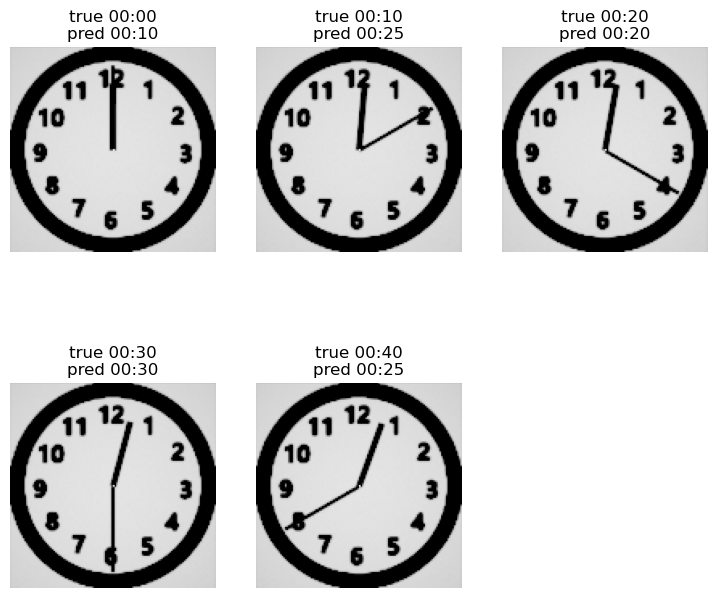

In [12]:
idx = slice(0,10, 2)
images, labels = dataset.get_images(idx)
items, _ = dataset.get_images(idx, False)
predicted = predict(items)
print(labels)
print(predicted)
show_images(images, labels, predicted)